In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suraj520/telecom-churn-dataset")

print("Path to dataset files:", path)

c:\Users\chandru.sivakumar\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\chandru.sivakumar\.cache\kagglehub\datasets\suraj520\telecom-churn-dataset\versions\1


In [2]:
import os
os.listdir(path)

['telecom_churn.csv']

In [3]:
import shutil

path_f = path+"\\telecom_churn.csv"

shutil.copy(path_f, "telecom_churn.csv")

'telecom_churn.csv'

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv(r"D:\CoWork\data\telecom_churn.csv")
df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [ ]:
print(df.shape)
df.dtypes

(243553, 14)


customer_id             int64
telecom_partner           str
gender                    str
age                     int64
state                     str
city                      str
pincode                 int64
date_of_registration      str
num_dependents          int64
estimated_salary        int64
calls_made              int64
sms_sent                int64
data_used               int64
churn                   int64
dtype: object

In [5]:
df["pincode"] = df["pincode"].astype(str)
df["date_of_registration"] = pd.to_datetime(df["date_of_registration"], errors="coerce")
df["churn"] = df["churn"].astype(bool)

In [6]:
df.isnull().sum()

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.shape

(243553, 14)

In [9]:
null_summary = pd.DataFrame({
    'null_count': df.isnull().sum(),
    'null_percentage': (df.isnull().sum() / len(df)) * 100
})

print(null_summary)

                      null_count  null_percentage
customer_id                    0              0.0
telecom_partner                0              0.0
gender                         0              0.0
age                            0              0.0
state                          0              0.0
city                           0              0.0
pincode                        0              0.0
date_of_registration           0              0.0
num_dependents                 0              0.0
estimated_salary               0              0.0
calls_made                     0              0.0
sms_sent                       0              0.0
data_used                      0              0.0
churn                          0              0.0


In [10]:
df.nunique()

customer_id             243553
telecom_partner              4
gender                       2
age                         57
state                       28
city                         6
pincode                 213442
date_of_registration      1220
num_dependents               5
estimated_salary        110032
calls_made                 119
sms_sent                    59
data_used                11837
churn                        2
dtype: int64

In [11]:
df.describe()

,customer_id,age,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used
count,243553.000000,243553.000000,243553,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,2021-09-01 00:00:00.354748,1.997500,85021.137839,49.010548,23.945404,4993.186025
min,1.000000,18.000000,2020-01-01 00:00:00,0.000000,20000.000000,-10.000000,-5.000000,-987.000000
25%,60889.000000,32.000000,2020-10-31 00:00:00,1.000000,52585.000000,24.000000,11.000000,2490.000000
50%,121777.000000,46.000000,2021-09-01 00:00:00,2.000000,84990.000000,49.000000,24.000000,4987.000000
75%,182665.000000,60.000000,2022-07-03 00:00:00,3.000000,117488.000000,74.000000,36.000000,7493.000000
max,243553.000000,74.000000,2023-05-04 00:00:00,4.000000,149999.000000,108.000000,53.000000,10991.000000
std,70307.839393,16.444029,NaN,1.414941,37508.963233,29.453556,14.733575,2942.019547


In [12]:
# count = df[df['churn']==1].shape[0]
churn_count = pd.DataFrame({
    "Status": ["Churned", "Not Churned"],
    "Count": [
        df[df['churn'] == 1].shape[0],
        df[df['churn'] == 0].shape[0]
    ]
})

churn_count

,Status,Count
0,Churned,48827
1,Not Churned,194726


In [13]:
neg_calls = (df['calls_made'] < 0).sum()
neg_sms = (df['sms_sent'] < 0).sum()
neg_data = (df['data_used'] < 0).sum()
print(neg_calls, neg_sms, neg_data)

6713 7375 6050


In [14]:
df[(df['calls_made'] < 0) | (df['sms_sent'] < 0) | (df['data_used'] < 0)]

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,False
19,20,Vodafone,M,26,Uttar Pradesh,Hyderabad,516585,2020-01-01,1,109753,95,-1,9993,False
33,34,BSNL,F,31,Haryana,Bangalore,830078,2020-01-01,2,106097,89,-2,3927,False
38,39,Reliance Jio,M,69,Gujarat,Chennai,712223,2020-01-01,1,87166,92,15,-790,False
68,69,Airtel,M,39,Kerala,Mumbai,413226,2020-01-01,2,121809,-1,13,8728,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243455,243456,BSNL,F,22,Chhattisgarh,Kolkata,371679,2023-05-03,4,107591,44,33,-459,False
243481,243482,Vodafone,F,61,Meghalaya,Chennai,964995,2023-05-03,3,59843,14,26,-529,False
243483,243484,BSNL,M,33,West Bengal,Chennai,745603,2023-05-03,1,127675,-3,24,1646,True
243484,243485,Reliance Jio,M,21,Maharashtra,Kolkata,938443,2023-05-03,2,92431,59,-1,8959,False


In [15]:
df[["calls_made","sms_sent","data_used"]].describe()

,calls_made,sms_sent,data_used
count,243553.000000,243553.000000,243553.000000
mean,49.010548,23.945404,4993.186025
std,29.453556,14.733575,2942.019547
min,-10.000000,-5.000000,-987.000000
25%,24.000000,11.000000,2490.000000
50%,49.000000,24.000000,4987.000000
75%,74.000000,36.000000,7493.000000
max,108.000000,53.000000,10991.000000


In [16]:
for col in ["calls_made", "sms_sent", "data_used"]:
    neg = df.loc[df[col] < 0, col]
    print(col, "neg range:", neg.min(), "to", neg.max(), "| pos median:", df.loc[df[col] >= 0, col].median())

calls_made neg range: -10 to -1 | pos median: 50.0
sms_sent neg range: -5 to -1 | pos median: 25.0
data_used neg range: -987 to -1 | pos median: 5112.0


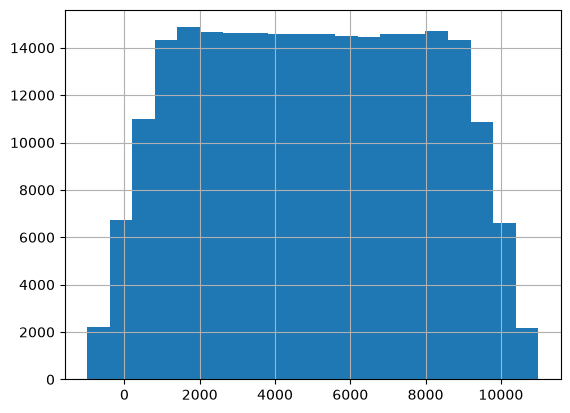

In [17]:
df["data_used"].hist(bins=20)
plt.show()

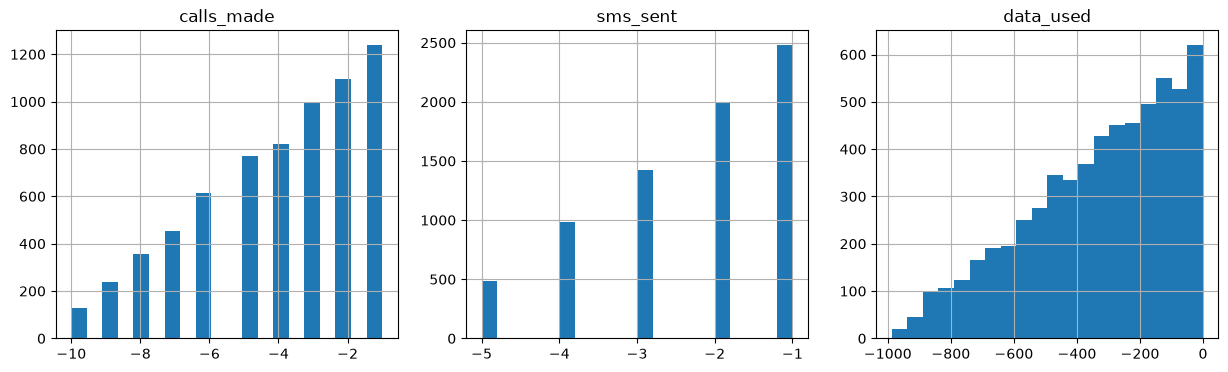

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ["calls_made", "sms_sent", "data_used"]):
    df.loc[df[col] < 0, col].hist(ax=ax, bins=20)
    ax.set_title(col)
plt.show()

In [19]:
df[["calls_made","sms_sent","data_used"]] = df[["calls_made","sms_sent","data_used"]].clip(lower= 0)

In [20]:
df[["calls_made","sms_sent","data_used"]].describe()

,calls_made,sms_sent,data_used
count,243553.000000,243553.000000,243553.000000
mean,49.120122,24.015754,5001.354802
std,29.260198,14.611419,2927.420055
min,0.000000,0.000000,0.000000
25%,24.000000,11.000000,2490.000000
50%,49.000000,24.000000,4987.000000
75%,74.000000,36.000000,7493.000000
max,108.000000,53.000000,10991.000000


In [21]:
df.dtypes

customer_id                      int64
telecom_partner                    str
gender                             str
age                              int64
state                              str
city                               str
pincode                            str
date_of_registration    datetime64[us]
num_dependents                   int64
estimated_salary                 int64
calls_made                       int64
sms_sent                         int64
data_used                        int64
churn                             bool
dtype: object

In [22]:
df.to_csv("telecom_churn_processed.csv", index=False)